In [2]:
#Imports
import math
import numpy as np
import matplotlib.pyplot as plt

Introduction

 The purpose of this project is to explain and prove the math behind traditional sailing which, for the purposes of this paper, will mean sailing deprived of any and all modern electronic or GPS assistance. The aim is to shed light on the science which made crossing vast oceans and circumnavigating the globe possible, by simulating a voyage across the Atlantic from Cadiz (Spain) to Santo Domingo (Dominican Republic) under different conditions. These simulations will show that even a tiny miscalculation on paper could have disastrous concequences in the open sea.

 This paper is divided into X parts - *list them* (some of which are divided into smaller sub-sections). *If needed go into detail on some or all of the sections*.  

Project Limitations

 Before setting sail, let us first touch upon the technical limitations of this endevour.
--> Will ignore historically established routes - I will calculate everything and then maybe use the historical one as an comparison.
--> Will ignore when the optimal months, currents and winds are for this journey, as some of those will be used as variable later on.
--> Will ignore variables such as fog or other ships entirely.
--> Will not be using a real nautical chart, only online resources
--> Compass and compass bearings?
--> Haven't explaine every little bit like why the radian conversion is as it it

Setting sail - the math behind planning a journey

 Our voyage begins at the port of Cadiz, Spain. Because of its strategic position between the Atlantic and the Mediterranean, and its proximity to Africa it was used as a main departure point for the "Fleet of the Indies" (Hurtado, 2020). The fleet was a Spanish maritime trade system from 1503 to 1789, connecting Spain with its American territories and the Philippines (Hurtado, 2020). From there, ships sailed to the port of Santo Domingo, the oldest port in the new world and Spain's first colony in the Americas (Onge, 2025), forming one of the nation's main maritime arteries at the time. It is this historical trade route that we shall take and model.

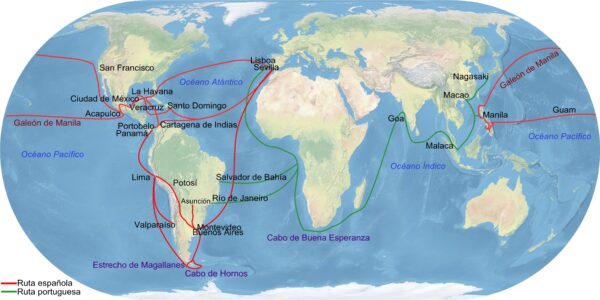
Image 1: Main trade routes of the Spanish and Portuguese empire (Hurtado, 2020)

 We are often taught that the shortest distance between two points is a straight line. Looking at a common world map, one would be tempeted to apply that same principle, forgetting that the map is drawn on a plane surface, while the Earth is anything but flat. The image above suggests that sailors knew that as well, in fact during the 'Colonial Age', European sailors and navigators were familiar with both plane and spherical geometry, and that ships sailed upon the surface of a sphere (Silverberg, 2005). During those times, humanity greatly advanced its geographical and navigational understandings, so let's put those discoveries to good use.

 In navigation, the Earth is assumed to be spherical instead of its irregular oblate spheroid shape, as this makes calculations easiear and introduces insignificant errors (Bowditch, 2002). The Earth is further divided into parallels and meridians, which are used to determine the lattitude and longitute, or the geographical coordinates, of points. These coordinates are the first things we need, in order to calculate and plot our course.
$$Port\:of\:Cadiz - 36^\circ\,32.12' \, \mathrm{N},\; 6^\circ\,16.95' \, \mathrm{W}$$
$$Port\:of\:Santo\:Domingo - 18^\circ\,28.01' \, \mathrm{N},\; 69^\circ\,52.87' \, \mathrm{W}$$
$${\tiny (marinetraffic, 2026)}$$

Similar to how parallels and meridians form a circle, we can further divide the globe into small and great circles. A great circle is a circle whose center coinsides with that of a sphere, while a small cirlce is a circle whose centre does not coincide  a sphere's (Cram Daily PH, 2021) (examples shown below).

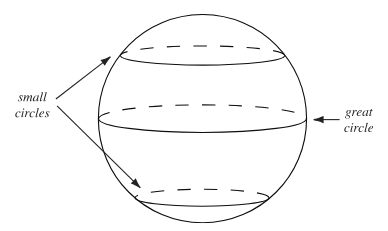
Image 2: Great and small circle example (wolfram, 2026)

Furthermore, great circles are the largest circles that can be drawn on the surface of a sphere, and are the shortest distance along the surface between any two points (Bowditch, 2002). Sailors take advantage of this and utilize it in what is called "great circle sailing", where the arc between the points is called a "great cirlce track" (Bowditch, 2002). This track is calculated, by drawing and solving a spherical traingle, which itself is a traingle enclosed in three great circle arcs (Cram Daily PH, 2021). 

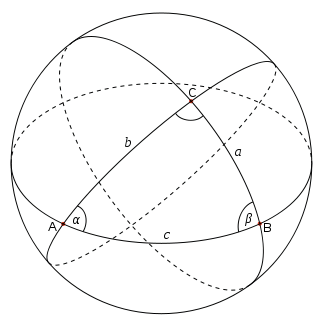
Image 3: Example of a spherical triangle (Cook, 2026)

As seen above, when drawing a spherical triangle we take the North pole as the third angle. We do this because we will be sailing in the northern hemisphere (Silverberg, 2005). If we were sailing below the equator, we would have taken the South pole. The other two lines are arcs of meridians, which give us the coresponding latitides. The mathematical discipline which will help solve this spherical triangle is called spherical trigonometry. From it, if the calculations are done by hand, one must use the spherical law of cosine. ##ADD INFO ON THE LAW AND PROOF##

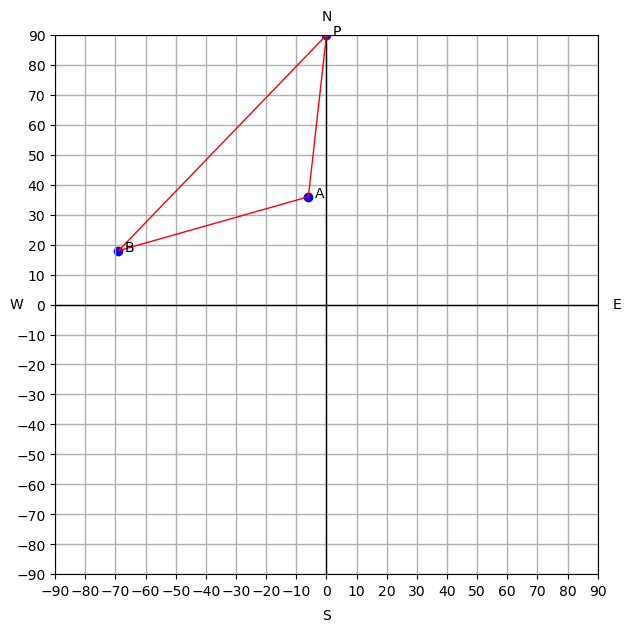

In [72]:
# Points (longitude, latitude)
P = (90, 0)
A = (36, -6)
B = (18, -69)

#Creates a blank graph with axes (1.0 by 1.0) (NE quadrant)
graph, axis = plt.subplots(figsize=(7,7))

#Sets the axes range (now it's more NE, SE quadrant into one)
axis.set_xlim(-90, 0)
axis.set_ylim(0, 90)

#Creates and defines the axes tick markers
degree_lines = [-90, -80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

axis.set_xticks(degree_lines)
axis.set_yticks(degree_lines)

#Turns the gridlines on, as per the above specifications
axis.grid(True, linestyle = "-", linewidth = 1)

#Draws the main axes and makes them stand out, like on a compass
axis.axhline(0, color = "black", linewidth=1)
axis.axvline(0, color = "black", linewidth=1)

#Positions the N,S and W,E compass symbols on the graph
axis.text(0, 95, "N", ha = "center", fontsize = 10)
axis.text(0, -105, "S", ha = "center", fontsize = 10)

axis.text(95, 0, "E", va = "center", fontsize = 10)
axis.text(-105, 0, "W", va = "center", fontsize = 10)

#Plots the three triangle points on the grapgh and adds markers next to them (PAB)
axis.scatter(P[1], P[0], color = "blue")
axis.scatter(A[1], A[0], color = "blue")
axis.scatter(B[1], B[0], color = "blue")

axis.text(P[1], P[0], "P")
axis.text(A[1], A[0], "A")
axis.text(B[1], B[0], "B")

#Connects the points and plots the triangle in red
triangle_x = [P[1], A[1], B[1], P[1]]
triangle_y = [P[0], A[0], B[0], P[0]]

axis.plot(triangle_x, triangle_y, color = "red", linewidth = 1)
plt.show()

The above traingle, although it is drawn on a flat plane, shows what we know so far. We have the coordinates of points A and B, which allows us to to calculate the sides PA and PB. We do this by substracting the latitude coordinates (N) from 90. The logic here is that the distance between the North pole and the Equater is 90 degrees (1 degree = 60 nauticle miles = 111.1 km (Australian National Maritime Museum, 2024)) so given that a latitude coordinate is a point between the pole and the equator we can substract it from the overall distance (greenemath, 2026). Another thing we can do is find the longitude distance between our two points, which will give point P's angle degrees (P = A longitude - B longitude). Having done that, we now have the following information:

$$A - 36^\circ\,32.12' \, \mathrm{N},\; 6^\circ\,16.95' \, \mathrm{W}$$
$$B - 18^\circ\,28.01' \, \mathrm{N},\; 69^\circ\,52.87' \, \mathrm{W}$$
$$P - 63^\circ\,36'$$
$$PA - 53^\circ\,28'$$
$$PB - 71^\circ\,32'$$

Now we need to find the difference in longitude between A and B. This is the great circle (shortest) distance between A and B. To do this, we plug in the numbers, we already have, into the sphericle law of cosin formula below (Steering Mariners, 2020):

$$\cos P = \frac{\cos AB - \cos PA \cdot \cos PB}{\sin PA \cdot \sin PB}$$
$$\cos 63^\circ\,36' = \frac{\cos AB - \cos 53^\circ\,28' \cdot \cos 71^\circ\,32'}{\sin 53^\circ\,28' \cdot \sin 71^\circ\,32'}$$

We can re-arrange the formula so that the unknow cosAB comes to the left side, leaving everything else on the right.

$$ cosAB = \cos P \cdot \sin PA \cdot \sin PB \cdot\cos PA \cdot \cos PB$$
$$ cosAB = \cos 63^\circ\,36' \cdot \sin 53^\circ\,28' \cdot \sin 71^\circ\,32' \cdot\cos 53^\circ\,28' \cdot \cos 71^\circ\,32'$$
 
After computing the above with a calculator, dividing the minutes by 60 so that we can convert them to coordinates (1 degree = 60 minutes), we are left with the below:

$$\cos AB  = 0.51$$
$$AB = \cos^{-1}(0.51)$$
$$AB = 59, 33^\circ\ $$
$$AB \cdot60 \approx 3560\;\text{Nautical Miles}$$

The above represent a crude calculation, which a navigator would have done by hand or with a calculator, before the advent of modern GPS systems. We will now do the same calculations in python and compare the results. We start by converting the minutes into coordinates, which will then be further transformed into radians, as python's math library accepts only radians for its trigonometric functions (Singh, 2024). Following this, we will again calculate the PA and PB sides of the triangle, as well as P's angle and will apply the law of cos.

In [54]:
#Functions I will be using:
#Converts minutes and seconds into degrees
def min_sec_to_deg (mins):
    return mins/60

#Converts degrees into radians
def degree_to_radian (degree):
    return degree * (math.pi / 180)

#Converts radians into degrees
def radian_to_degree (radian):
    return radian * (180 / math.pi)

#Difference in longtitude formula
def dlo (long_one, long_two):
    return long_one - long_two

#The law of cos
def cos_law (b,c, d):
    return math.cos(b) * math.cos(c) + math.sin(b) * math.sin(c) * math.cos(d)

#Convert the minutes and seconds into degrees
#We divide by 60 and add the numbers after the decimal point to the coordinates. As this method of calculation allows for more accuracy, 
# I will add four numbers, after the decimal point.
print(f"Transformed Cadiz minutes = {min_sec_to_deg(32.12):.4f} and {min_sec_to_deg(16.95):.4f}")
print(f"Transformed Santo Domingo minutes = {min_sec_to_deg(28.01):.4f} and {min_sec_to_deg(52.87):.4f}")

#Cadiz coordinates
cadiz_lat = 36.5353
cadiz_long = 6.2825

lat_1_N = degree_to_radian(36.5353)
long_1_W = degree_to_radian(6.2825)

print(f"\nCadiz's lat and long in transformed degrees is {cadiz_lat}N, {cadiz_long}W and in radians - {lat_1_N:.4f}, {long_1_W:.4f}")

#Santo Domingo coordinates
san_dom_lat = 18.4668
san_dom_long = 69.8811

lat_2_N = degree_to_radian(18.4668)
long_2_W = degree_to_radian(69.8811)

print(f"Santo Domingo's lat and long in transformed degrees is {san_dom_lat}N, {san_dom_long}W and in radians - {lat_2_N:.4f}, {long_2_W:.4f}")

#Find side PA
side_pa = 90 - cadiz_lat
side_pa_radian = degree_to_radian(side_pa)

#Find side PB
side_pb = 90 - san_dom_lat
side_pb_radian = degree_to_radian(side_pb)

#Find the difference in longitude, which is P angle's degrees
p_angle = dlo(san_dom_long, cadiz_long)
p_angle_radian = degree_to_radian(p_angle)

#Using the law of cos
side_ab_radians = math.acos(cos_law (side_pa_radian, side_pb_radian, p_angle_radian))
side_ab_degrees = radian_to_degree(side_ab_radians)

print(f"\nSide AB in degrees is {side_ab_degrees:.4f}; side AB in radians is {side_ab_radians:.4}")

#Getting the great circle distance (gcd) in nautical miles
gcd = side_ab_degrees * 60
print(f"The shortest route between Cadiz and Santo Domingo is {gcd:.4f}")

Transformed Cadiz minutes = 0.5353 and 0.2825
Transformed Santo Domingo minutes = 0.4668 and 0.8812

Cadiz's lat and long in transformed degrees is 36.5353N, 6.2825W and in radians - 0.6377, 0.1097
Santo Domingo's lat and long in transformed degrees is 18.4668N, 69.8811W and in radians - 0.3223, 1.2197

Side AB in degrees is 58.1666; side AB in radians is 1.015
The shortest route between Cadiz and Santo Domingo is 3489.9989
